# Cafe Sales Analysis
### Business Scenario
You've been hired as a junior data analyst by a cafe. The  Cafe has provided the transaction and wants to understand its sales performance. 

In [42]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
#load the data
df = pd.read_csv("C:/Users/KINN/Desktop/PYTHON FOR DATA ANALYTICS AND DATA APPS/dirty_cafe_sales.csv")

In [44]:
#preview the data
#by deafult we see the first five but if I wanted 10 it becomes df.head(10)
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [45]:
#preview last five rows
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [46]:
#random samples
df.sample(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2730,TXN_9004306,Coffee,4,2.0,8.0,Credit Card,In-store,2023-05-26
5664,TXN_8464222,Cake,4,3.0,12.0,Cash,In-store,2023-08-17
6761,TXN_3617989,Sandwich,3,4.0,12.0,Credit Card,Takeaway,2023-09-29
2754,TXN_6158865,Cookie,1,1.0,1.0,Digital Wallet,NaN,2023-11-27
6047,TXN_1696300,Cookie,1,1.0,1.0,Digital Wallet,In-store,2023-05-28
5494,TXN_8075323,Sandwich,1,4.0,4.0,Digital Wallet,NaN,2023-04-18
9799,TXN_6826409,Sandwich,1,4.0,4.0,Credit Card,Takeaway,2023-10-21
6276,TXN_8647048,Sandwich,2,4.0,8.0,Credit Card,In-store,2023-11-03
127,TXN_9096052,Smoothie,4,4.0,16.0,Credit Card,Takeaway,2023-12-28
6872,TXN_1309055,UNKNOWN,2,2.0,4.0,Credit Card,Takeaway,2023-11-09


In [47]:
#def information for data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


Our data set has  missing values. 
some columns have incorrect data types.

In [48]:
#statistical summary using a function called describe. 
# Gives a statistical summary such as mean, standard deviation etc. 
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [49]:
#selecting columns. 
df['Item']

0         Coffee
1           Cake
2         Cookie
3          Salad
4         Coffee
          ...   
9995      Coffee
9996         NaN
9997      Coffee
9998      Cookie
9999    Sandwich
Name: Item, Length: 10000, dtype: str

In [50]:
#to see the first five in a column
df['Item'].head()

0    Coffee
1      Cake
2    Cookie
3     Salad
4    Coffee
Name: Item, dtype: str

In [51]:
#Selecting Multiple columns
df[['Item', 'Price Per Unit']].head()

,Item,Price Per Unit
0,Coffee,2.0
1,Cake,3.0
2,Cookie,1.0
3,Salad,5.0
4,Coffee,2.0


In [52]:
#checking for data type for specific column
df['Quantity'].dtype

<StringDtype(storage='python', na_value=nan)>

In [53]:
#checking data types
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

### Data Quality

In [54]:
#Check if there is missing values. we use isnull().sum() or isna().sum() function.
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [55]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [56]:
#Check for duplicates as they can inflate your findings. 
df.duplicated().sum()

np.int64(0)

### Data Cleaning. 
We do cleaning first. 
order matters. What do you want to do:
Never start by removing the missing values. 
#### Cleaning order: 
1. Hidden Errors to be removed such as 'UNKNOWN' and 'ERROR'
2. Fix Data Types.
3. Drop missing values. 

In [57]:
#Remove the Hidden Errors
invalid_values = ['UNKNOWN', 'ERROR', 'NA', '?']

#Replace these missing values with NaN across the entire dataframe.
df.replace(invalid_values, np.nan, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [58]:
#Fixing the data types
#change quantity, price per unit, total spent change them to numeric

df['Quantity']=pd.to_numeric (df['Quantity'], errors='coerce')
df['Price Per Unit']=pd.to_numeric (df['Price Per Unit'], errors='coerce')
df['Total Spent']=pd.to_numeric (df['Total Spent'], errors='coerce')

In [59]:
#change transaction date to date and time
df['Transaction Date']=pd.to_datetime (df['Transaction Date'], errors='coerce')

In [60]:
#Drop missing Values
df=df.dropna()

In [61]:
#clean texts 
# eg Coffee = COFFEE = coffee =     Coffee

df['Item'] = df['Item'].str.strip().str.title()

# Validation

In [62]:
#Recheck for missing Values
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [63]:
#Dataset Shape checking
df.shape

(3089, 8)

In [64]:
# Checking the Items
df['Item'].unique()

<StringArray>
['Coffee', 'Cake', 'Salad', 'Sandwich', 'Juice', 'Smoothie', 'Cookie', 'Tea']
Length: 8, dtype: str

In [65]:
# Check data types
df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [66]:
#Statistical summary now
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,3089.000000,3089.000000,3089.000000,3089
mean,3.023632,2.954030,8.936711,2023-07-01 07:14:28.242149
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-03-28 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-06 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-01 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.418931,1.292975,6.032656,NaN


# Business Questions


In [67]:
# How many sales did each product have?
df['Item'].value_counts()

Item
Juice       427
Salad       418
Sandwich    391
Cookie      391
Cake        385
Tea         372
Coffee      367
Smoothie    338
Name: count, dtype: int64

In [68]:
#What product is the best seller?
df['Item'].value_counts().idxmax()

'Juice'

In [69]:
#what is the average quantity ordered per transaction?
df['Quantity'].mean()

np.float64(3.0236322434444802)

In [70]:
#what is the total quantity sold?
df['Quantity'].sum()

np.float64(9340.0)

In [71]:
#creating a new column
df['Revenue'] = df['Quantity']* df['Price Per Unit']
#Preview the Data
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Revenue
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,25.0
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03,8.0


In [72]:
# What is the total revenue
df['Revenue'].sum()

np.float64(27605.5)

In [73]:
#Average Revenue
df['Revenue'].mean()

np.float64(8.936710909679508)

In [74]:
#Revenue per Item
df.groupby('Item')['Revenue'].sum()

Item
Cake        3519.0
Coffee      2242.0
Cookie      1163.0
Juice       3735.0
Salad       6360.0
Sandwich    4772.0
Smoothie    4088.0
Tea         1726.5
Name: Revenue, dtype: float64

In [75]:
#Sorting
df.groupby('Item')['Revenue'].sum().sort_values(ascending= False)

Item
Salad       6360.0
Sandwich    4772.0
Smoothie    4088.0
Juice       3735.0
Cake        3519.0
Coffee      2242.0
Tea         1726.5
Cookie      1163.0
Name: Revenue, dtype: float64

In [76]:
# Quantity ordered per item
df.groupby('Item')['Quantity'].sum()

Item
Cake        1173.0
Coffee      1121.0
Cookie      1163.0
Juice       1245.0
Salad       1272.0
Sandwich    1193.0
Smoothie    1022.0
Tea         1151.0
Name: Quantity, dtype: float64

# VISUALISATION

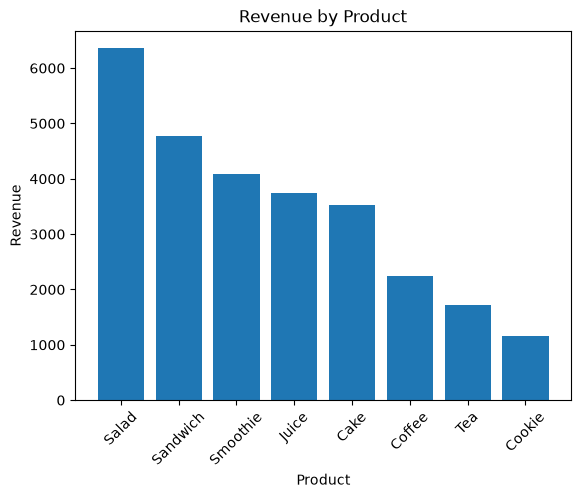

In [77]:
#sales per item
#Barchat

sales_by_item = df.groupby('Item')['Revenue'].sum().sort_values(ascending=False) #Data we are using

plt.bar(sales_by_item.index, sales_by_item.values)
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
#to deal with the spill over for texts, we rotate  them on X axis to a certain angle eg
plt.xticks(rotation=45)
plt.show()

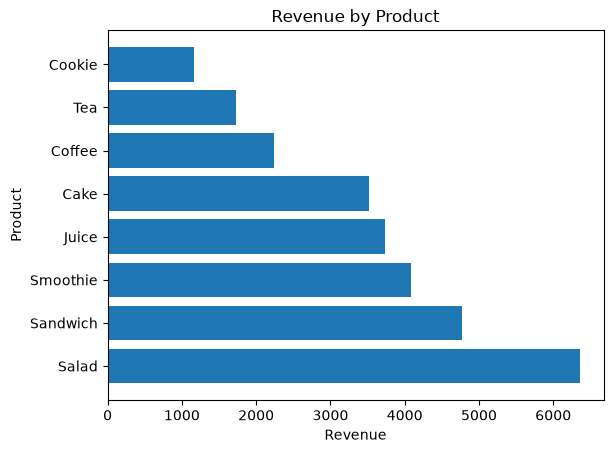

In [78]:
# Using horizontal  bar for normal  ones where it starts with the normal value
#We use it to make the captions visible
sales_by_item = df.groupby('Item')['Revenue'].sum().sort_values(ascending=False)

plt.barh(sales_by_item.index, sales_by_item.values)
plt.title('Revenue by Product')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

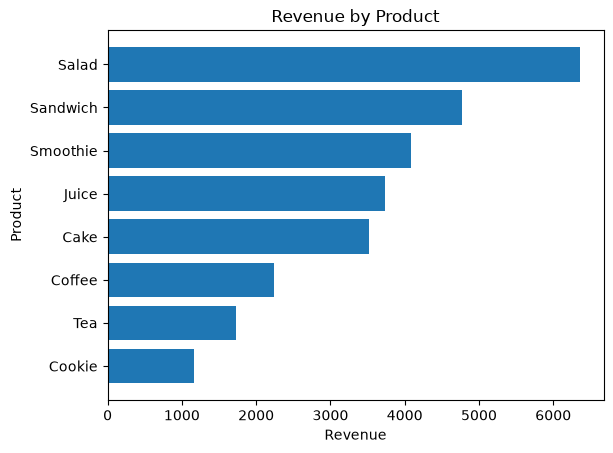

In [79]:
# Using horizontal  bar making it reverse order
#We use it to make the captions visible
sales_by_item = df.groupby('Item')['Revenue'].sum().sort_values(ascending=False)

plt.barh(sales_by_item.index[::-1], sales_by_item.values[::-1])
plt.title('Revenue by Product')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

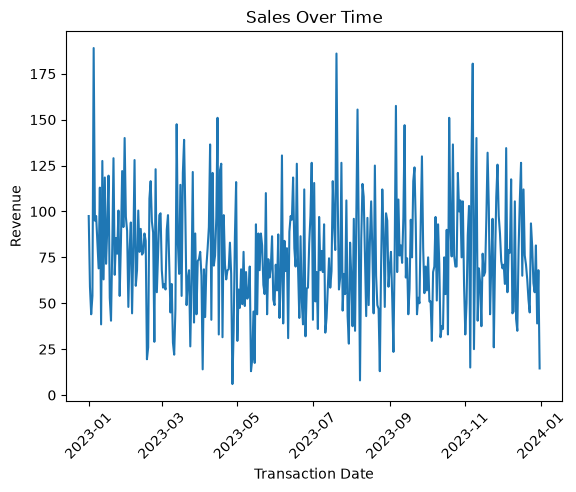

In [80]:
#sales per day
#Line graph shows trends  eg sales over time. 

sales_per_day = df.groupby('Transaction Date')['Revenue'].sum()
plt.plot(sales_per_day.index, sales_per_day.values)
plt.title('Sales Over Time')
plt.xlabel('Transaction Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

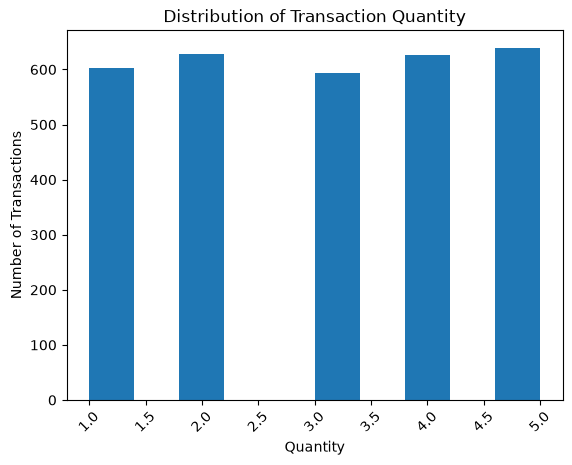

In [81]:
# Plotting a Histogram. Shows you distribution. 
# Shows how things are distributed such as the range of salaries. 
#For Maximum and the minimum earners.
# How are transaction quantities distributed?

plt.hist(df['Quantity'], bins=10)
plt.title('Distribution of Transaction Quantity')
plt.xlabel('Quantity')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()


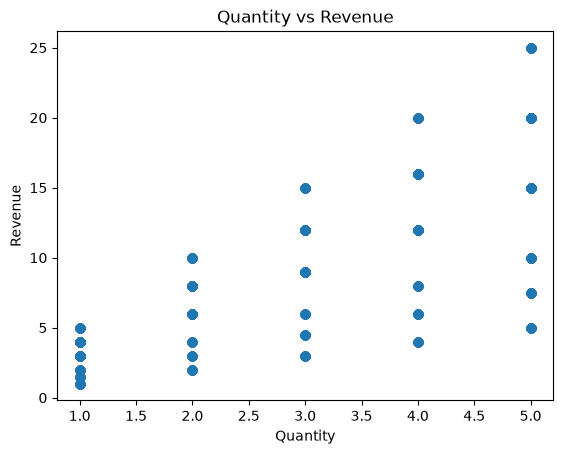

In [82]:
# Scatter plot. Investigates the relationship between two variables e.g
#Relationship between quantity sold and the revenue

plt.scatter(df['Quantity'], df['Revenue'])
plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.show()